# Agriculture and Income: Does a Farming Economy Mean a richer Country

** PyData Data Science Foundations, Week 5 Capstone
** Three World Bank indicator files, joined by country and year

This notebook walks through the six CRISP-DM phases, in order:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment (charts, then the Streamlit app)

## Phase 1: Business Understanding

*Written before looking at any results.*

**Research Question (one sentence):** Do countries with a larger agriculture share of GDP or a greater share of agricultural land tend to have lower GDP per capita?

**Business Understanding:** Many countries depend heavily on agriculture, but the relationship between agricultural dependence and economic development may differ across countries and over time. Understanding this relationship can help governments and development organisations identify whether a greater reliance on agriculture is associated with lower income levels.

This project examines the relationship between agriculture's share of GDP, agricultural land, and GDP per capita across countries from 1960 to 2025.

**What a good answer lets someone decide:** Governments and development organisations could use the findings to understand whether agricultural dependence is associated with lower income levels and whether countries with different levels of agricultural dependence show different economic-development patterns.

**Hypothesis:**
- **H₀:** There is no significant relationship between agricultural dependence and GDP per capita.
- **H₁:** There is a significant negative relationship between agricultural dependence and GDP per capita.

**Important limitation:** This project investigates association, not causation. A negative relationship would not by itself show that agricultural dependence causes lower GDP per capita.


## Setup: tools and file locations

This cell loads the tools we need and finds the three World Bank files. You do not need to change anything here.

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

data_folder = Path.cwd() / "NEW DATA"
if not data_folder.is_dir():
    data_folder = Path.cwd().parent / "NEW DATA"
if not data_folder.is_dir():
    raise FileNotFoundError("Put the 'NEW DATA' folder in the project folder.")

gdp_file = next(data_folder.glob(
    "API_NY.GDP.PCAP.CD_*/API_NY.GDP.PCAP.CD_*.csv"
))
agri_gdp_file = next(data_folder.glob(
    "API_NV.AGR.TOTL.ZS_*/API_NV.AGR.TOTL.ZS_*.csv"
))
agri_land_file = next(data_folder.glob(
    "API_AG.LND.AGRI.ZS_*/API_AG.LND.AGRI.ZS_*.csv"
))
country_info_file = next(data_folder.glob(
    "API_NY.GDP.PCAP.CD_*/Metadata_Country_*.csv"
))

first_year = 1960   # earliest year we will look at
last_year = 2025    # latest year we will look at
min_years = 10      # a country needs at least this many years of data

print("Data folder:", data_folder)
print("Years:", first_year, "to", last_year)

Data folder: c:\Users\MARTIN\capstone-martin\NEW DATA
Years: 1960 to 2025


## Phase 2: Data Understanding

Before joining anything, we look at each raw file on its own: its size, its column types, and how much is missing.

The World Bank files are "wide": one row per country and one column per year. We skip the first 4 lines of each file because they are a description, not data.

In [13]:
raw_gdp = pd.read_csv(gdp_file, skiprows=4)
raw_agri_gdp = pd.read_csv(agri_gdp_file, skiprows=4)
raw_agri_land = pd.read_csv(agri_land_file, skiprows=4)

raw_tables = {
    "GDP per capita (US$)": raw_gdp,
    "Agriculture, % of GDP": raw_agri_gdp,
    "Agricultural land, % of land area": raw_agri_land,
}

for name, table in raw_tables.items():
    # The year columns are the ones whose names are digits, like "1960", "2020".
    year_columns = [c for c in table.columns if str(c).isdigit()]
    percent_missing = table[year_columns].isna().mean().mean() * 100

    print(name)
    print("  shape (rows, columns):", table.shape)
    print("  column types:", table.dtypes.astype(str).value_counts().to_dict())
    print("  share of year cells that are empty:", round(percent_missing, 1), "%")
    print()

GDP per capita (US$)
  shape (rows, columns): (265, 71)
  column types: {'float64': 67, 'str': 4}
  share of year cells that are empty: 15.7 %

Agriculture, % of GDP
  shape (rows, columns): (265, 71)
  column types: {'float64': 67, 'str': 4}
  share of year cells that are empty: 35.0 %

Agricultural land, % of land area
  shape (rows, columns): (265, 71)
  column types: {'float64': 67, 'str': 4}
  share of year cells that are empty: 13.8 %



**What this tells us:** each file has one row per country or group (about 260 rows), with a column per year. A good chunk of the cells are empty, which is normal for World Bank data: not every country reports every indicator every year. Some rows are groups such as "World" or "Euro area", not countries. We deal with both in Phase 3.

### Central tendency and spread

To keep this simple we look at one recent year, 2020, for each indicator. We report the mean (typical value), the median (middle value), and the standard deviation (how spread out the values are).

In [14]:
snapshot_year = "2020"

summary = pd.DataFrame({
    name: table[snapshot_year].describe()
    for name, table in raw_tables.items()
})

summary.loc["median"] = [table[snapshot_year].median() for table in raw_tables.values()]
summary.loc["skewness"] = [table[snapshot_year].skew() for table in raw_tables.values()]
summary.round(2)

,GDP per capita (US$),"Agriculture, % of GDP","Agricultural land, % of land area"
count,257.00,245.00,257.00
mean,16365.92,10.39,37.53
std,24409.79,9.55,20.97
min,252.70,0.01,0.50
25%,2167.22,2.47,20.80
50%,6133.33,7.54,39.43
75%,19966.48,16.93,49.39
max,176891.81,40.69,84.56
median,6133.33,7.54,39.43
skewness,3.11,1.06,0.12


### Distribution of GDP per capita

A histogram shows how the values are spread. If the mean is much bigger than the median, the data is usually skewed to the right (a few very large values pull the mean up).

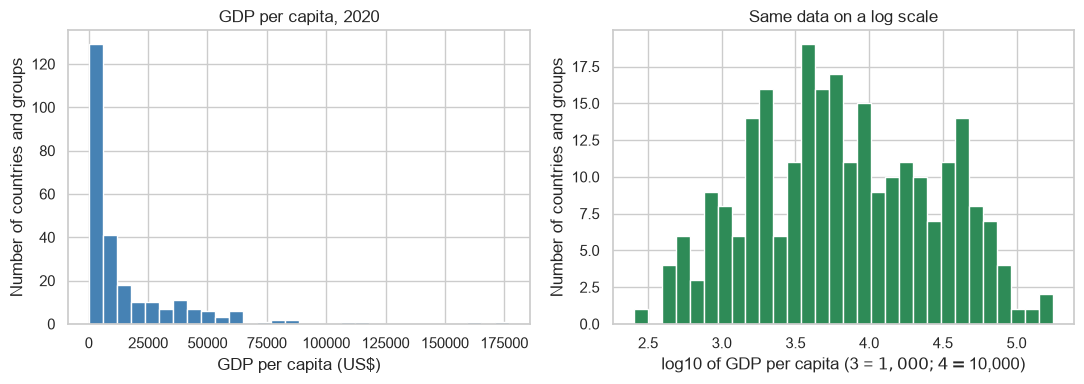

Mean:   16366
Median: 6133


In [15]:
gdp_2020 = raw_gdp[snapshot_year].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(gdp_2020, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("GDP per capita, " + snapshot_year)
axes[0].set_xlabel("GDP per capita (US$)")
axes[0].set_ylabel("Number of countries and groups")

axes[1].hist(np.log10(gdp_2020), bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("Same data on a log scale")
axes[1].set_xlabel("log10 of GDP per capita (3 = $1,000; 4 = $10,000)")
axes[1].set_ylabel("Number of countries and groups")

plt.tight_layout()
plt.show()

print("Mean:  ", round(gdp_2020.mean()))
print("Median:", round(gdp_2020.median()))

**Shape of the distribution:** *(check this against your chart and fix it if needed)* The left histogram is strongly **right-skewed**: most countries have a modest GDP per person and a few have very high values, so the mean is larger than the median. On the log scale (right) the shape is much closer to a bell shape. Because of this, from here on we use the **log of GDP per capita** for correlations and tests, since they work better on roughly symmetric data.

## Phase 3: Data Preparation

Now we turn three wide, messy files into one tidy table with one row per country and year.

### Step 1: Keep real countries only

The World Bank files also include groups like "World" and "Low income". Only real countries and territories have a **Region** filled in, so we use that to filter.

In [16]:
country_info = pd.read_csv(country_info_file)

real_countries = country_info[country_info["Region"].notna()]   # keep rows that have a Region
real_country_codes = list(real_countries["Country Code"])        # make a list of their codes

print("Number of real countries and territories:", len(real_country_codes))

Number of real countries and territories: 217


### Step 2: A reusable cleaning function

The same cleaning steps are needed for all three files, so we write them once as a function:
1. Drop columns we do not need.
2. Turn the wide table into a long one (one row per country and year) using `melt`.
3. Drop empty cells, keep our years, keep real countries, and remove duplicates.

In [17]:
def load_and_clean(file_path, new_column_name):

    table = pd.read_csv(file_path, skiprows=4)

    # Drop columns we do not need
    table = table.drop(columns=["Indicator Name", "Indicator Code"])
    empty_columns = [name for name in table.columns if name.startswith("Unnamed")]
    table = table.drop(columns=empty_columns)

    # Wide -> long: one row per country and year
    table = table.melt(
        id_vars=["Country Name", "Country Code"],
        var_name="Year",
        value_name=new_column_name
    )

    table = table.dropna()                       # remove empty cells
    table["Year"] = table["Year"].astype(int)    # years were text, make them numbers

    # Keep only the years we want
    table = table[(table["Year"] >= first_year) & (table["Year"] <= last_year)]

    # Keep only real countries (not groups like "World")
    table = table[table["Country Code"].isin(real_country_codes)]

    # Remove any accidental duplicate rows
    table = table.drop_duplicates(subset=["Country Code", "Year"])

    return table

print("Cleaning function is ready.")

Cleaning function is ready.


### Step 3: Clean the three tables

In [18]:
gdp = load_and_clean(gdp_file, "GDP_per_capita")
agri_gdp = load_and_clean(agri_gdp_file, "Agriculture_GDP")
agri_land = load_and_clean(agri_land_file, "Agriculture_Land")

print("GDP per capita:    ", len(gdp), "rows,", gdp["Country Code"].nunique(), "countries")
print("Agriculture % GDP: ", len(agri_gdp), "rows,", agri_gdp["Country Code"].nunique(), "countries")
print("Agricultural land: ", len(agri_land), "rows,", agri_land["Country Code"].nunique(), "countries")

gdp.head()

GDP per capita:     11764 rows, 214 countries
Agriculture % GDP:  9088 rows, 206 countries
Agricultural land:  12121 rows, 210 countries


,Country Name,Country Code,Year,GDP_per_capita
9,Argentina,ARG,1960,778.251707
13,Australia,AUS,1960,1813.431099
14,Austria,AUT,1960,939.914815
16,Burundi,BDI,1960,70.905100
17,Belgium,BEL,1960,1290.286072


### Step 4: Join the three tables

We match rows on **Country Code** and **Year**.

**Decision: a left join, starting from GDP.** An `inner` join keeps only country-years that appear in all three tables, which throws away many rows. A `left` join keeps every GDP row and leaves a blank where the other two tables have no value. This keeps the joined table above the 10,000-row requirement, and each later analysis simply ignores the blanks it cannot use.

We show the row counts before and after so the effect of the join is visible.

In [19]:
# Country Name is only needed once, so drop it from the two smaller tables
agri_gdp_small = agri_gdp.drop(columns=["Country Name"])
agri_land_small = agri_land.drop(columns=["Country Name"])

match_on = ["Country Code", "Year"]

# For comparison only: how many rows would an inner join keep?
inner_rows = len(
    gdp.merge(agri_gdp_small, on=match_on, how="inner")
       .merge(agri_land_small, on=match_on, how="inner")
)

df = gdp.merge(agri_gdp_small, on=match_on, how="left")
df = df.merge(agri_land_small, on=match_on, how="left")

print("BEFORE the join:")
print("  GDP table:               ", len(gdp), "rows")
print("  Agriculture % GDP table: ", len(agri_gdp), "rows")
print("  Agricultural land table: ", len(agri_land), "rows")
print()
print("AFTER the join:")
print("  Left join (what we keep):", len(df), "rows,", df["Country Code"].nunique(), "countries")
print("  Inner join (for comparison):", inner_rows, "rows")

df.head()

BEFORE the join:
  GDP table:                11764 rows
  Agriculture % GDP table:  9088 rows
  Agricultural land table:  12121 rows

AFTER the join:
  Left join (what we keep): 11764 rows, 214 countries
  Inner join (for comparison): 8510 rows


,Country Name,Country Code,Year,GDP_per_capita,Agriculture_GDP,Agriculture_Land
0,Argentina,ARG,1960,778.251707,NaN,NaN
1,Australia,AUS,1960,1813.431099,NaN,NaN
2,Austria,AUT,1960,939.914815,NaN,NaN
3,Burundi,BDI,1960,70.905100,NaN,NaN
4,Belgium,BEL,1960,1290.286072,NaN,NaN


### Step 5: Clean the joined table

Three checks, each with a reason:
- **Too few years:** a country with fewer than 10 years of data tells us little about trends, so we remove it.
- **Zeros that are really missing:** an agriculture share of exactly 0% for a whole country is very unlikely (the first draft showed Brazil at 0.0 in 1961). We treat those zeros as missing, not as true values, so they do not pull results down.
- **Impossible values:** percentages must be between 0 and 100 and GDP per person must be above 0.

In [20]:
# 1. Remove countries with too few years of data
years_per_country = df.groupby("Country Code")["Year"].transform("count")
removed_names = df[years_per_country < min_years]["Country Name"].unique()
print("Removed for having fewer than", min_years, "years:", list(removed_names))
df = df[years_per_country >= min_years]

# 2. Treat an agriculture share of exactly 0 as missing
zero_rows = df[df["Agriculture_GDP"] == 0]
print("Rows with Agriculture_GDP exactly 0:", len(zero_rows))
print("Countries affected:", list(zero_rows["Country Name"].unique())[:10])
df = df.copy()
df["Agriculture_GDP"] = df["Agriculture_GDP"].replace(0, np.nan)

# 3. Remove impossible values (blank cells are not flagged here)
bad_rows = (
    (df["GDP_per_capita"] <= 0)
    | (df["Agriculture_GDP"] < 0) | (df["Agriculture_GDP"] > 100)
    | (df["Agriculture_Land"] < 0) | (df["Agriculture_Land"] > 100)
)
print("Impossible rows removed:", bad_rows.sum())
df = df[~bad_rows]

df = df.sort_values(["Country Name", "Year"]).reset_index(drop=True)
print()
print("Rows after cleaning:", len(df))

Removed for having fewer than 10 years: ['South Sudan', 'St. Martin (French part)']
Rows with Agriculture_GDP exactly 0: 42
Countries affected: ['Brazil', 'Venezuela, RB']
Impossible rows removed: 0

Rows after cleaning: 11752


### Step 6: Create new columns

Our question needs a few new columns:
- `Log_GDP`: the log of GDP per person (we saw in Phase 2 that GDP is skewed).
- `Agri_Group`: "High" or "Low" agriculture share of GDP, split at the median.
- `Land_Group`: "Low", "Medium" or "High" agricultural land, split into three equal-sized groups.
- `Period`: "Before 2000" or "2000 and later", for the before/after comparison in Phase 5.

In [21]:
df["Log_GDP"] = np.log10(df["GDP_per_capita"])

median_agri = df["Agriculture_GDP"].median()
df["Agri_Group"] = np.where(df["Agriculture_GDP"] > median_agri, "High", "Low")
df.loc[df["Agriculture_GDP"].isna(), "Agri_Group"] = np.nan

df["Land_Group"] = pd.qcut(df["Agriculture_Land"], 3, labels=["Low", "Medium", "High"])

df["Period"] = np.where(df["Year"] < 2000, "Before 2000", "2000 and later")

print("Median agriculture share of GDP (the High/Low cut-off):", round(median_agri, 1), "%")
df.head()

Median agriculture share of GDP (the High/Low cut-off): 11.0 %


,Country Name,Country Code,Year,GDP_per_capita,Agriculture_GDP,Agriculture_Land,Log_GDP,Agri_Group,Land_Group,Period
0,Afghanistan,AFG,2000,174.930991,NaN,57.945817,2.242867,NaN,High,2000 and later
1,Afghanistan,AFG,2001,138.706822,NaN,57.947350,2.142098,NaN,High,2000 and later
2,Afghanistan,AFG,2002,178.954088,38.627892,57.939684,2.252742,High,High,2000 and later
3,Afghanistan,AFG,2003,198.871116,37.418855,58.083805,2.298572,High,High,2000 and later
4,Afghanistan,AFG,2004,221.763654,29.721067,58.151266,2.345890,High,High,2000 and later


### Step 7: Final check and save

Some blanks remain on purpose, because the left join kept country-years where one of the agriculture indicators is not reported. Each analysis below removes only the blanks it needs.

In [22]:
print("FINAL DATA:", df.shape[0], "rows,", df["Country Code"].nunique(), "countries,",
      "years", df["Year"].min(), "to", df["Year"].max())
print()
print("Blank cells per column:")
print(df.isna().sum())

if df.shape[0] < 10000:
    print()
    print("WARNING: fewer than 10,000 rows. The brief requires at least 10,000.")

# Save in the project folder so it can be committed to GitHub for the Streamlit app
output_file = Path.cwd() / "capstone_clean.csv"
df.to_csv(output_file, index=False)
print()
print("Saved to:", output_file)

FINAL DATA: 11752 rows, 212 countries, years 1960 to 2025

Blank cells per column:
Country Name           0
Country Code           0
Year                   0
GDP_per_capita         0
Agriculture_GDP     2733
Agriculture_Land     947
Log_GDP                0
Agri_Group          2733
Land_Group           947
Period                 0
dtype: int64

Saved to: c:\Users\MARTIN\capstone-martin\capstone_clean.csv


## Phase 4: Modeling

The brief asks for a correlation or probability-based quantity that uses columns from more than one original file. We compute two:
1. **Correlation:** how strongly does GDP per capita move together with the agriculture columns?
2. **Conditional probability:** if a country-year has a high agriculture share, how likely is it to be a high-income one?

We only use rows where all three values are present.

In [23]:
model_df = df.dropna(subset=["Log_GDP", "Agriculture_GDP", "Agriculture_Land"]).copy()
print("Rows with all three values:", len(model_df))

# 1. Correlation (Pearson) between log GDP and the two agriculture columns
corr_table = model_df[["Log_GDP", "Agriculture_GDP", "Agriculture_Land"]].corr(method="pearson")
print()
print(corr_table.round(2))

r_share, p_share = stats.pearsonr(model_df["Agriculture_GDP"], model_df["Log_GDP"])
r_land, p_land = stats.pearsonr(model_df["Agriculture_Land"], model_df["Log_GDP"])
print()
print("Log GDP vs agriculture share of GDP: r =", round(r_share, 3))
print("Log GDP vs agricultural land:        r =", round(r_land, 3))

Rows with all three values: 8465

                  Log_GDP  Agriculture_GDP  Agriculture_Land
Log_GDP              1.00            -0.82             -0.21
Agriculture_GDP     -0.82             1.00              0.16
Agriculture_Land    -0.21             0.16              1.00

Log GDP vs agriculture share of GDP: r = -0.816
Log GDP vs agricultural land:        r = -0.207


In [24]:
# 2. Conditional probability: P(high income | agriculture group)
median_log_gdp = model_df["Log_GDP"].median()
model_df["High_Income"] = model_df["Log_GDP"] > median_log_gdp

p_overall = model_df["High_Income"].mean()
p_by_group = model_df.groupby("Agri_Group")["High_Income"].mean()

print("P(high income), all country-years:         ", round(p_overall, 3))
print("P(high income | HIGH agriculture share):   ", round(p_by_group["High"], 3))
print("P(high income | LOW agriculture share):    ", round(p_by_group["Low"], 3))

P(high income), all country-years:          0.5
P(high income | HIGH agriculture share):    0.122
P(high income | LOW agriculture share):     0.882


**What this suggests (in plain language):** *(fill in after running the cells above, using your real numbers)*

- A correlation (r) near **-1** means a high agriculture share goes with a low GDP per person; near **0** means little link; near **+1** means the opposite. Say which one you found and whether it matches your hypothesis.
- If the chance of being high-income is very different for high and low agriculture groups, then agriculture share and income are **not independent**. If the two chances are close to each other, they look independent.
- Remember: a correlation shows that two things move together, not that one causes the other.

## Phase 5: Evaluation (hypothesis tests)

We run three tests, all at **α = 0.05**:

| Test | Type | Question |
|---|---|---|
| 1 | t-test (core) | Is GDP per person different in high- vs low-agriculture-share countries? |
| 2 | ANOVA / F-test (core) | Is GDP per person different across low, medium and high agricultural land? |
| 3 | Two-proportion Z-test (A/B-style) | Were agriculture-heavy economies less common after 2000 than before? |

**What a p-value is:** if H0 were true, the p-value is how likely we would be to see a result at least this extreme.
**What it is *not*:** it is **not** the probability that H0 is true, and it does not tell us how big or important the effect is.

**A warning about our data:** each country appears many times (one row per year), so the rows are not fully independent, and with thousands of rows even tiny differences can look "significant". So we also look at the size of the difference, not only the p-value.

In [25]:
alpha = 0.05

def decide(p_value):
    if p_value < alpha:
        return "p < 0.05, so we REJECT H0."
    return "p >= 0.05, so we FAIL TO REJECT H0."

### Test 1: t-test (high vs low agriculture share)

- **H0:** average log GDP per capita is the same in high- and low-agriculture-share country-years.
- **H1:** the averages are different.
- **Why a t-test:** we compare the means of two groups on a numeric variable. We use Welch's version, which does not assume equal spread.

In [26]:
high_agri = model_df[model_df["Agri_Group"] == "High"]["Log_GDP"]
low_agri = model_df[model_df["Agri_Group"] == "Low"]["Log_GDP"]

t_stat, p_t = stats.ttest_ind(high_agri, low_agri, equal_var=False)

print("Mean log GDP, high agriculture share:", round(high_agri.mean(), 2),
      "(about $", round(10 ** high_agri.mean()), "per person)")
print("Mean log GDP, low agriculture share: ", round(low_agri.mean(), 2),
      "(about $", round(10 ** low_agri.mean()), "per person)")
print()
print("t statistic:", round(t_stat, 2))
print("p-value:    ", p_t)
print(decide(p_t))

Mean log GDP, high agriculture share: 2.84 (about $ 686 per person)
Mean log GDP, low agriculture share:  3.97 (about $ 9253 per person)

t statistic: -104.8
p-value:     0.0
p < 0.05, so we REJECT H0.


**Interpretation:** *(write one sentence using your real numbers, for example)* "Country-years with a high agriculture share had a lower average GDP per person than those with a low share, and the difference is larger than we would expect from chance alone (p < 0.05). This does not mean there is a 5% chance H0 is true, and it does not by itself say agriculture *causes* low income."

### Test 2: ANOVA (low, medium and high agricultural land)

- **H0:** average log GDP per capita is the same in all three land groups.
- **H1:** at least one group has a different average.
- **Why ANOVA:** we compare the means of **three** groups, so a t-test is not enough. The F-test checks them all at once.

In [27]:
land_groups = [
    model_df[model_df["Land_Group"] == name]["Log_GDP"]
    for name in ["Low", "Medium", "High"]
]

f_stat, p_f = stats.f_oneway(*land_groups)

for name, values in zip(["Low", "Medium", "High"], land_groups):
    print("Mean log GDP,", name, "agricultural land:", round(values.mean(), 2),
          "(about $", round(10 ** values.mean()), "per person)")
print()
print("F statistic:", round(f_stat, 2))
print("p-value:    ", p_f)
print(decide(p_f))

Mean log GDP, Low agricultural land: 3.67 (about $ 4672 per person)
Mean log GDP, Medium agricultural land: 3.28 (about $ 1904 per person)
Mean log GDP, High agricultural land: 3.28 (about $ 1922 per person)

F statistic: 250.9
p-value:     1.3871852618716654e-106
p < 0.05, so we REJECT H0.


**Interpretation:** *(write one sentence using your real numbers)* ANOVA only tells us that **at least one** group differs, not which one. Say whether the averages above show a steady pattern (for example, GDP falling as land rises) or no clear pattern. If you fail to reject H0, that is still a real finding: it means agricultural land alone does not separate richer from poorer countries.

### Test 3 (A/B-style): before 2000 vs 2000 and later

- **Groups:** country-years before 2000 vs country-years from 2000 onwards.
- **Outcome:** is the country "agriculture-heavy", meaning agriculture is **more than 20% of GDP**?
- **H0:** the share of agriculture-heavy country-years is the same before and after 2000.
- **H1:** the shares are different.
- **Why a two-proportion Z-test:** we compare two proportions (yes/no outcomes) from two groups.

**Important:** countries were **not randomly assigned** to "before" or "after". Time simply passed. A significant result shows that the two periods **differ**. It does **not** prove what caused the difference, the way a true randomized A/B test could.

In [28]:
test_df = df.dropna(subset=["Agriculture_GDP"]).copy()
test_df["Agri_Heavy"] = test_df["Agriculture_GDP"] > 20

before = test_df[test_df["Period"] == "Before 2000"]["Agri_Heavy"]
after = test_df[test_df["Period"] == "2000 and later"]["Agri_Heavy"]

x1, n1 = before.sum(), len(before)
x2, n2 = after.sum(), len(after)
p1, p2 = x1 / n1, x2 / n2

# Two-proportion z-test, step by step
p_pooled = (x1 + x2) / (n1 + n2)
standard_error = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
z_stat = (p1 - p2) / standard_error
p_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Agriculture-heavy before 2000:  ", round(p1 * 100, 1), "% of", n1, "country-years")
print("Agriculture-heavy 2000 onwards: ", round(p2 * 100, 1), "% of", n2, "country-years")
print()
print("z statistic:", round(z_stat, 2))
print("p-value:    ", p_z)
print(decide(p_z))

Agriculture-heavy before 2000:   45.8 % of 4021 country-years
Agriculture-heavy 2000 onwards:  20.0 % of 4998 country-years

z statistic: 26.29
p-value:     0.0
p < 0.05, so we REJECT H0.


**Interpretation:** *(write one sentence using your real numbers)* Say how the share changed and whether the change is statistically significant. Then repeat the caution: because the groups were not randomly assigned, this shows the periods differ, not why.

## Phase 6: Deployment (charts)

Three charts that a reader who has never seen the code can understand. Each is saved to a `figures` folder so the Streamlit app can use them.

In [29]:
figures_folder = Path.cwd() / "figures"
figures_folder.mkdir(exist_ok=True)

### Chart 1: GDP per person vs agriculture share of GDP

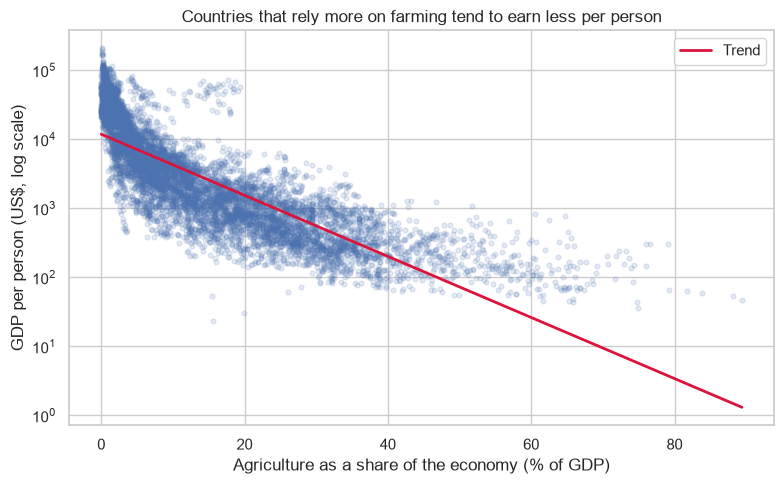

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(model_df["Agriculture_GDP"], model_df["GDP_per_capita"], alpha=0.15, s=12)

# Trend line: fit a straight line to log GDP, then convert back to dollars
slope, intercept = np.polyfit(model_df["Agriculture_GDP"], model_df["Log_GDP"], 1)
x_line = np.linspace(model_df["Agriculture_GDP"].min(), model_df["Agriculture_GDP"].max(), 100)
ax.plot(x_line, 10 ** (intercept + slope * x_line), color="crimson", linewidth=2, label="Trend")

ax.legend()
ax.set_yscale("log")
ax.set_title("Countries that rely more on farming tend to earn less per person")
ax.set_xlabel("Agriculture as a share of the economy (% of GDP)")
ax.set_ylabel("GDP per person (US$, log scale)")

plt.tight_layout()
fig.savefig(figures_folder / "chart1_gdp_vs_agriculture_share.png", dpi=150)
plt.show()

### Chart 2: GDP per person by amount of agricultural land

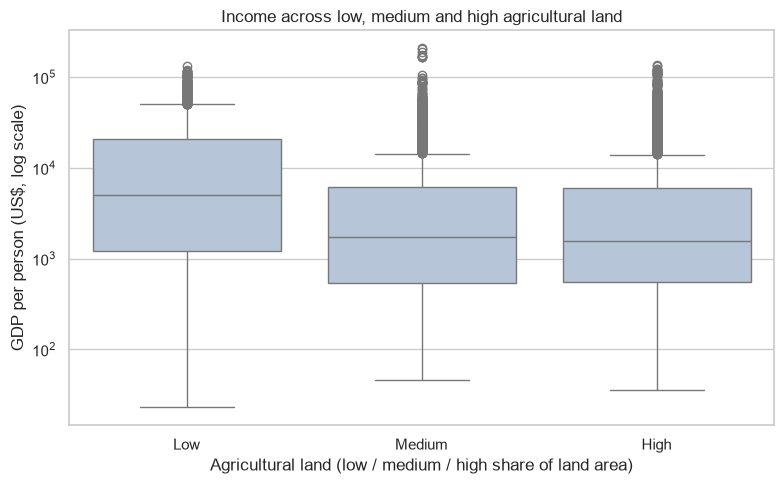

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=model_df, x="Land_Group", y="GDP_per_capita",
    order=["Low", "Medium", "High"], color="lightsteelblue", ax=ax
)
ax.set_yscale("log")
ax.set_title("Income across low, medium and high agricultural land")
ax.set_xlabel("Agricultural land (low / medium / high share of land area)")
ax.set_ylabel("GDP per person (US$, log scale)")

plt.tight_layout()
fig.savefig(figures_folder / "chart2_gdp_by_land_group.png", dpi=150)
plt.show()

### Chart 3: Agriculture's share of the economy over time

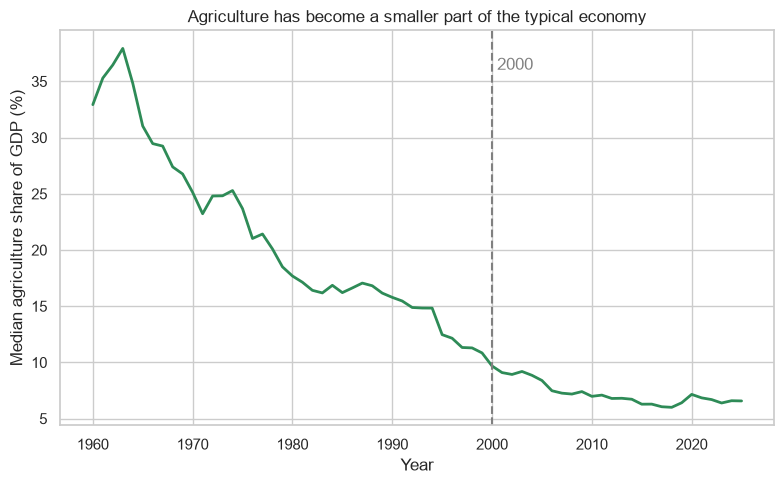

In [32]:
over_time = test_df.groupby("Year")["Agriculture_GDP"].median().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(over_time["Year"], over_time["Agriculture_GDP"], color="seagreen", linewidth=2)
ax.axvline(2000, color="grey", linestyle="--")
ax.text(2000.5, over_time["Agriculture_GDP"].max() * 0.95, "2000", color="grey")
ax.set_title("Agriculture has become a smaller part of the typical economy")
ax.set_xlabel("Year")
ax.set_ylabel("Median agriculture share of GDP (%)")

plt.tight_layout()
fig.savefig(figures_folder / "chart3_agriculture_share_over_time.png", dpi=150)
plt.show()

## Recommendation and conclusion


- What did you find about agriculture share and income? Compare it with your hypothesis from Phase 1.
- What did you find about agricultural land?
- What would you recommend to the people in your Phase 1 decision?
- What are the limits? Mention that correlation is not causation, that countries appear many times in the data, and that the before/after groups were not randomly assigned.

